In [2]:
from DFTStructureGenerator import B_N_Cl, xtb_process, mol_manipulation
import glob, os, shutil, itertools, copy
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Geometry import Point3D
import numpy as np
from tqdm import tqdm
import pandas as pd

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from matplotlib import pyplot as plt

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [5]:
# DFT Method In Need
#p opt=(maxcycles=150) freq b3lyp/6-31g(d) em=gd3bj scrf=(smd,solvent=toluene) nosymm
OPT_METHOD = "opt freq b3lyp/6-31g(d) em=gd3bj scrf=(smd,solvent=toluene) nosymm"
SPE_METHOD = "wb97xd/6-311+g(d,p) scrf=(smd,solvent=toluene) nosymm"
SPE_WFN_METHOD = "wb97xd/6-311+g(d,p) scrf=(smd,solvent=toluene) nosymm output=wfn"
OM_METHOD = "opt=(modredundant,maxcycles=100) freq b3lyp/6-31g(d) em=gd3bj scrf=(smd,solvent=toluene) nosymm"
TS_METHOD = "opt=(calcfc,ts,noeigen,maxcycles=100) freq b3lyp/6-31g(d) em=gd3bj scrf=(smd,solvent=toluene) nosymm"
SPE_SPECIAL = "b3lyp/6-31g(d) em=gd3bj scrf=(smd,solvent=toluene) nosymm"

In [6]:
# root_file = "G:/work/B_Cl_Nu/Data"                    # 数据存储的核心目录
root_file = "G:/work/B_Cl_Nu2/Data" 
if not os.path.isdir(root_file):
    os.mkdir(root_file)
mol_xtb_file = os.path.join(root_file, 'Mol_xtb')       # 存储Xtb数据的目录  
if not os.path.isdir(mol_xtb_file):
    os.mkdir(mol_xtb_file)         
mol_dir = os.path.join(root_file, 'Mols')              # 存储Mol文件的目录
dft_dir = os.path.join(root_file, 'GS_OPT')             # 存储DFT数据的目录
spe_dir = os.path.join(root_file, 'GS_SPE')                # 存储SPE数据的目录

文件目录嵌套关系
- Data              # 所有数据储存的地址，即root_file
  - GS_OPT          # 基态优化的DFT文件夹
    - B_N_r         # B自由基和配体的复合物-反应物自由基的优化
    - B_N_r_improve # 脚本默认生成的Gaussian改错文件地址
    - dustbin       # 计算失败的log
  - Mols            # Mol文件夹
  - Mol_xtb         # Xtb计算的输出地址


# 1 数据整理

In [11]:
def test(a,b,c,d=2):
    print(a,b,c,d)
dict_ = {"a":1, "b":2, "c":3}
test(**dict_, d=4)

1 2 3 4


In [125]:
B_N_Cl.generate_combinations(
    reactant_file='Data/Reactants.csv',
    result_file='Data/Processed_Reactants.csv',
)

## 1 产生B\N单体优化结构，XTB找构象

In [ ]:
import dscribe

In [133]:
B_N_Cl.B_N_Single_Xtb(root_file=root_file,
    result_file='Data/Processed_Reactants.csv', 
    mol_xtb_name = "Mol_xtb")


[18:57:49] UFFTYPER: Unrecognized charge state for atom: 1
[18:57:49] UFFTYPER: Unrecognized charge state for atom: 1
[18:57:49] UFFTYPER: Unrecognized charge state for atom: 2
[18:57:49] UFFTYPER: Unrecognized charge state for atom: 2


In [19]:
mol = mol_manipulation.smiles2mol("CC1CC(C)(C)CC(OOC(C)(C)C)(OOC(C)(C)C)C1", conf_num=1)
AllChem.UFFOptimizeMolecule(mol)

0

# 2 DFT结构搭建

In [ ]:
all_strs = ['B', 'Other']
all_spins = [2,1]
for name, spin in zip(all_strs, all_spins):
    mol_xtb_file = os.path.join(root_file, 'Mol_xtb')
    root_dir = mol_xtb_file + "/" + name
    mol_dir = os.path.join(root_file, 'Mols')
    dft_dir = root_file + "/GS_OPT"
    if not os.path.isdir(dft_dir):
        os.mkdir(dft_dir)

    dft_dir_ = root_file + "/GS_OPT" + "/" + name
    if not os.path.isdir(dft_dir_):
        os.mkdir(dft_dir_)

    B_N_Cl.smiles_DFT_calc(root_dir, mol_dir, dft_dir_, method = OPT_METHOD, conf_limit = 10, SpinMultiplicity=spin) 

In [26]:
# 错误排查
mol_manipulation.error_improve(dft_dir, mol_dir, 'Other', 'dust_bin', improve_dir='Other_imp')

[18:30:23] Warning: molecule is tagged as 3D, but all Z coords are zero


In [135]:
B_N_Cl.SPE_DFT_calc(root_file, 'GS_OPT/B', 'GS_SPE/B', "Mols", method=SPE_METHOD)

In [24]:
spe_dir = os.path.join(root_file, 'GS_SPE2')

In [31]:
mol_manipulation.error_improve(spe_dir, mol_dir, 'Other', 'dust_bin', improve_dir='Other_imp')

In [ ]:
mol_manipulation.error_improve(spe_dir, mol_dir, 'B_N_p_new', 'dust_bin', improve_dir='B_N_p_new_imp')

In [136]:
B_N_Cl.SPE_DFT_calc_wfn(root_file, 'GS_OPT', 'GS_SPE_wfn', method=SPE_WFN_METHOD)

 76%|███████▌  | 69/91 [00:04<00:01, 14.10it/s][19:13:21] Warning: molecule is tagged as 3D, but all Z coords are zero
[19:13:21] Warning: molecule is tagged as 3D, but all Z coords are zero
100%|██████████| 91/91 [00:07<00:00, 12.83it/s]


In [ ]:
B_N_Cl.SPE_DFT_calc_wfn(root_file, 'GS_OPT/B_N_p_d', 'GS_SPE_wfn/B_N_p_d', method=SPE_WFN_METHOD)

100%|██████████| 49203/49203 [08:14<00:00, 99.45it/s] 


In [137]:
# 反应物计算完成整理
B_N_Cl.collection_dft_single(
    result_path = 'Data/Processed_Reactants.csv', 
    mol_dir=mol_dir, dft_dir=dft_dir, spe_dir=spe_dir)


91it [00:03, 28.45it/s]


# 3 模型训练

## 传统描述符

In [5]:
react_df = pd.read_csv('Data/Processed_Reactants.csv')
all_smiles = list(set(react_df['Smiles'].to_list()))
B_df = react_df.loc[react_df['Type'] == "B"]
S_df = react_df.loc[react_df['Type'] == "S"]
ini_df = react_df.loc[react_df['Type'] == "ini"]
sol_df = react_df.loc[react_df['Type'] == "sol"]
eqs = [1.5, 2.0, 2.5, 3.0]
target_idx = np.array(np.meshgrid(np.arange(len(B_df['Index'])), np.arange(len(S_df['Index'])), np.arange(len(ini_df['Index'])), np.arange(len(sol_df['Index'])), np.arange(len(eqs)))).T.reshape(-1, 5)
B_mols = [Chem.MolFromSmiles(smi) for smi in B_df['Smiles']]
S_mols = [Chem.MolFromSmiles(smi) for smi in S_df['Smiles']]
ini_mols = [Chem.MolFromSmiles(smi) for smi in ini_df['Smiles']]
B_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)) for mol in B_mols])
S_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)) for mol in S_mols])
ini_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)) for mol in ini_mols])
sol_fps = np.eye(len(sol_df))
eqs_fps = np.eye(len(eqs))
B_dict = {B_df['Index'].iloc[i]: B_fps[i] for i in range(len(B_df))}
S_dict = {S_df['Index'].iloc[i]: S_fps[i] for i in range(len(S_df))}
ini_dict = {ini_df['Index'].iloc[i]: ini_fps[i] for i in range(len(ini_df))}
sol_dict = {sol_df['Index'].iloc[i]: sol_fps[i] for i in range(len(sol_df))}
eqs_dict = {eqs[i]: eqs_fps[i] for i in range(len(eqs))}

In [6]:
result_csv = pd.read_excel("Data/Iteration/Result_n_001.xlsx")
result_csv.dropna(inplace=True)
all_X = []
yields = []
for row_id, row in result_csv.iterrows():
    desc = []
    B = int(row['B_Index'])
    B_eq = row['eqs']
    ini = int(row['ini_Index'])
    sol = int(row['sol_Index'])
    S = int(row['S_Index'])
    desc += B_dict[B].tolist()
    desc += ini_dict[ini].tolist()
    desc += sol_dict[sol].tolist()
    desc += S_dict[S].tolist()
    desc += [B_eq]
    all_X.append(desc)
    yields.append(row['yield'])
all_X_mf = np.array(all_X)
yields = np.array(yields)


## 高级描述符

In [ ]:
[len(index_map[key]) for key in index_map.keys()]

In [7]:
from morfeus import BuriedVolume
SOL_KEY = {3016:9, 3017:6, 3018:3, 3019:1, 3020:0.33}
target_csv = pd.read_csv('Data/Processed_Reactants.csv')
index_map = {}
for line_id, line in tqdm(target_csv.iterrows()):
    pre_Index = int(line['Index'])
    if pre_Index >= 3016 and pre_Index <= 3020:
        Index = 3003
        line = target_csv.loc[target_csv['Index'] == Index].iloc[0]
    else:
        Index = pre_Index
    Smiles = line['Smiles']
    Atomid = int(line['Atomid'])
    conf = int(line['conf_idxs'])
    G_eng = line['G_energy']
    type_ = line['Type']
    
    mol = B_N_Cl.mol_manipulation.smiles2mol(Smiles)
    react_name = f"{Index:05}_{conf:04}.log"
    log = B_N_Cl.logfile_process.Logfile(dft_dir + "/" + react_name)
    mol = Chem.MolFromMolFile(mol_dir + "/" + f'{Index:05}.mol', removeHs=False, sanitize=False)
    
    # BNreact
    descriptor = [G_eng]
    descriptor += log.read_orbit_eng()
    descriptor += [log.get_dipole()]
    position = log.first_atom_position
    charges, spins = log.read_charge_spin_density()
    if type_ == "B":
        descriptor += [spins[Atomid]]
    elif type_ == "BNCl":
        another_Atomid = [each for each in mol.GetAtoms() if each.GetSymbol() == 'B'][0].GetIdx()
    elif type_ == "S":
        another_Atomid = [each for each in mol.GetAtomWithIdx(Atomid).GetNeighbors() if each.GetSymbol() != 'H'][0].GetIdx()
    elif type_ == 'ini':
        descriptor += [Atomid + 273.15]
        if mol.HasSubstructMatch(Chem.MolFromSmarts("N=N")):
            Atomid = mol.GetSubstructMatches(Chem.MolFromSmarts("N=N"))[0][0]
            another_Atomid = [each for each in mol.GetAtomWithIdx(Atomid).GetNeighbors() if each.GetSymbol() != 'N'][0].GetIdx()
        elif mol.HasSubstructMatch(Chem.MolFromSmarts("OO")):
            Atomid = mol.GetSubstructMatches(Chem.MolFromSmarts("OO"))[0][0]
            another_Atomid = [each for each in mol.GetAtomWithIdx(Atomid).GetNeighbors() if each.GetSymbol() != 'O'][0].GetIdx()
    elif type_ == 'sol':
        if pre_Index in SOL_KEY.keys():
            descriptor += [SOL_KEY[pre_Index]]
        else:
            descriptor += [0]
    if type_ not in ['B', 'sol']:
        descriptor += [charges[Atomid], charges[another_Atomid]]
        descriptor += [B_N_Cl.Tool.get_atoms_distance(position[Atomid], position[another_Atomid])]

        symbol_lists = log.symbol_list
        position = log.first_atom_position
        bv = BuriedVolume(symbol_lists, position, Atomid + 1, include_hs=1, radius=2, z_axis_atoms=[another_Atomid + 1], excluded_atoms=[another_Atomid + 1])
        bv.octant_analysis()
        descriptor += [np.sum(list(bv.octants['percent_buried_volume'].values())[:4])]
        bv = BuriedVolume(symbol_lists, position, Atomid + 1, include_hs=1, radius=4, z_axis_atoms=[another_Atomid + 1], excluded_atoms=[another_Atomid + 1])
        bv.octant_analysis()
        descriptor += [np.sum(list(bv.octants['percent_buried_volume'].values())[:4])]
        bv = BuriedVolume(symbol_lists, position, Atomid + 1, include_hs=1, radius=6, z_axis_atoms=[another_Atomid + 1], excluded_atoms=[another_Atomid + 1])
        bv.octant_analysis()
        descriptor += [np.sum(list(bv.octants['percent_buried_volume'].values())[:4])]
    index_map[pre_Index] = descriptor

4it [00:00,  9.51it/s][15:50:29] UFFTYPER: Unrecognized charge state for atom: 1
30it [00:03,  3.81it/s][15:50:32] UFFTYPER: Unrecognized charge state for atom: 2
92it [00:23,  3.87it/s]


## 氯底物描述符

In [89]:
Cl_des_map.keys()

dict_keys(['Cl_00443', 'Cl_00444', 'Cl_00445', 'Cl_00446', 'Cl_00447', 'Cl_00448', 'Cl_00449', 'Cl_00450', 'Cl_00451', 'Cl_00452', 'Cl_00453', 'Cl_00454', 'Cl_00455', 'Cl_00456', 'Cl_00457', 'Cl_00458', 'Cl_00459', 'Cl_00460', 'Cl_00461', 'Cl_00462', 'Cl_00463', 'Cl_00464', 'Cl_00465', 'Cl_00466', 'Cl_00467', 'Cl_00468', 'Cl_00469', 'Cl_00470', 'Cl_00471', 'Cl_00472', 'Cl_00473', 'Cl_00474', 'Cl_00475', 'Cl_00476', 'Cl_00477', 'Cl_00478', 'Cl_00479', 'Cl_00480', 'Cl_00481', 'Cl_00482', 'Cl_00483', 'Cl_00484', 'Cl_00485', 'Cl_00486', 'Cl_00487', 'Cl_00488', 'Cl_00489', 'Cl_00490', 'Cl_00491', 'Cl_00492', 'Cl_00493', 'Cl_00494', 'Cl_00495', 'Cl_00496', 'Cl_00497', 'Cl_00498', 'Cl_00499', 'Cl_00500', 'Cl_00501', 'Cl_00502', 'Cl_00503', 'Cl_00504', 'Cl_00505', 'Cl_00506', 'Cl_00507', 'Cl_00508', 'Cl_00509', 'Cl_00510', 'Cl_00511', 'Cl_00512', 'Cl_00513', 'Cl_00514', 'Cl_00515', 'Cl_00516', 'Cl_00517', 'Cl_00518', 'Cl_00519', 'Cl_00520', 'Cl_00522', 'Cl_00523', 'Cl_00524', 'Cl_00525', 'Cl_0

In [101]:
import pickle
with open("Data/Cldes_.pkl", 'rb') as f:
    Cl_des_map = pickle.load(f)
# Cl_00712, Cl_00713, Cl_00714
Cl_des_map_new = {'Cl_05000':Cl_des_map['Cl_00712'], 'Cl_05001_Claid_00015':Cl_des_map['Cl_00713_Claid_00015'], 'Cl_05001_Claid_00019':Cl_des_map['Cl_00713_Claid_00019'], 'Cl_05002_Claid_00015':Cl_des_map['Cl_00714_Claid_00015'], 'Cl_05002_Claid_00017':Cl_des_map['Cl_00714_Claid_00017'],'Cl_05002_Claid_00020':Cl_des_map['Cl_00714_Claid_00020'] }
with open("Data/Cldes_new.pkl", 'wb') as f:
    pickle.dump(Cl_des_map_new, f)

In [8]:
import pickle
with open("Data/Cldes_new.pkl", 'rb') as f:
    Cl_des_map = pickle.load(f)

## 反应描述符生成

In [9]:
def descriptor_generator(csv_file):
    if type(csv_file) == str:
        result_csv = pd.read_excel(csv_file).dropna()
    else:
        result_csv = csv_file.dropna()
    all_X = []
    yields = []
    for row_id, row in result_csv.iterrows():
        desc = []
        B = int(row['B_Index'])
        B_eq = row['eqs']
        ini = int(row['ini_Index'])
        sol_1 = int(row['sol_Index'])
        S = int(row['S_Index'])
        if "Cl_Index" in result_csv.columns:
            Cl = int(row['Cl_Index'])
            Cl_atomid = int(row['Cl_Atomid'])
            if Cl in [5001, 5002]:
                desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
            else:
                desc += Cl_des_map[f"Cl_{Cl:05d}"]
        desc += index_map[B]
        desc += index_map[ini]
        desc += index_map[sol_1]
        desc += index_map[S]
        desc += [B_eq]
        all_X.append(desc)
        yields.append(row['yield'])
    yields = np.array(yields)
    all_X_qm = np.array(all_X)
    return all_X_qm, yields


## 回归模型

In [28]:
all_X_qm, yields = descriptor_generator("Data/Iteration/Result_sum_00021.xlsx")

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
all_X = all_X_qm
# all_X = np.concatenate([all_X_mf, all_X_qm], axis=1)
all_r2s, all_f1s, all_acc, all_preds = [], [], [], np.zeros(len(all_X))
result_matrix = np.zeros((2, 2))
target = yields
for train_ids, test_ids in kf.split(all_X):
    # model = RandomForestRegressor(n_estimators=200, random_state=0)
    # model = XGBRegressor(n_estimators=100, random_state=0)
    # model = GradientBoostingRegressor(n_estimators=200, random_state=0)
    model = CatBoostRegressor(iterations=10000, random_seed=0, verbose=0, depth=2)
    model.fit(all_X[train_ids], target[train_ids])
    pred = model.predict(all_X[test_ids])
    r2 = r2_score(target[test_ids], pred)
    all_r2s.append(r2)
    print("R2: ", r2)
    a = target[test_ids] > 20
    b = pred > 20
    r2 = accuracy_score(a,b)
    print("Accuracy: ", r2)
    all_acc.append(r2)
    r2 = f1_score(a,b)
    print("F1: ",r2)
    all_f1s.append(r2)
    result_matrix += confusion_matrix(a,b)
    all_preds[test_ids] = pred
print(np.mean(all_r2s))


R2:  0.6329380586848801
Accuracy:  0.88
F1:  0.896551724137931
R2:  0.7401712338651496
Accuracy:  0.86
F1:  0.8813559322033898
R2:  0.6915847120047627
Accuracy:  0.8571428571428571
F1:  0.904109589041096
R2:  0.8098416834783754
Accuracy:  0.8775510204081632
F1:  0.9090909090909091
R2:  0.7789327797935605
Accuracy:  0.9183673469387755
F1:  0.9393939393939394
0.7306936935653456


## 分类模型

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import KFold
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

kf = KFold(n_splits=5, shuffle=True, random_state=1)
all_X = all_X_qm
# all_X = np.concatenate([all_X_mf, all_X_qm], axis=1)
all_f1s, all_acc, all_preds = [], [], np.zeros(len(all_X))
result_matrix = np.zeros((2, 2))
target = np.array([1 if each > 20 else 0 for each in yields])
for train_ids, test_ids in kf.split(all_X):
    # model = RandomForestClassifier(n_estimators=200, random_state=0)
    # model = XGBClassifier(n_estimators=100, random_state=0)
    # model = GradientBoostingClassifier(n_estimators=200, random_state=0)
    model = CatBoostClassifier(iterations=10000, random_seed=0, verbose=0, depth=2)
    model.fit(all_X[train_ids], target[train_ids])
    pred = model.predict(all_X[test_ids])
    r2 = accuracy_score(target[test_ids], pred)
    print("Accuracy: ", r2)
    all_acc.append(r2)
    r2 = f1_score(target[test_ids], pred)
    print("F1: ",r2)
    all_f1s.append(r2)
    result_matrix += confusion_matrix(target[test_ids], pred)
    
    all_preds[test_ids] = pred
result_matrix = result_matrix / 4
print(np.mean(all_acc), np.mean(all_f1s))


Accuracy:  0.8695652173913043
F1:  0.888888888888889
Accuracy:  0.8260869565217391
F1:  0.8620689655172413
Accuracy:  0.8222222222222222
F1:  0.8857142857142857
Accuracy:  0.8888888888888888
F1:  0.9019607843137255
Accuracy:  0.9555555555555556
F1:  0.967741935483871
0.872463768115942 0.9012749719836025


In [138]:
result_matrix *4 / len(all_preds)

array([[0.53636364, 0.05454545],
       [0.02727273, 0.38181818]])

In [137]:
1 - np.sum(target) / len(target)

0.5909090909090908

### 迁移学习部分

# 4 贝叶斯优化

## 4.1 初始数据集

In [30]:
react_df = pd.read_csv('Data/Processed_Reactants.csv')
all_smiles = list(set(react_df['Smiles'].to_list()))
B_df = react_df.loc[react_df['Type'] == "B"]
S_df = react_df.loc[react_df['Type'] == "S"]
ini_df = react_df.loc[react_df['Type'] == "ini"]
sol_df = react_df.loc[react_df['Type'] == "sol"]
eqs = [1.5, 2.0, 2.5, 3.0]
target_idx = np.array(np.meshgrid(np.arange(len(B_df['Index'])), np.arange(len(S_df['Index'])), np.arange(len(ini_df['Index'])), np.arange(len(sol_df['Index'])), np.arange(len(eqs)))).T.reshape(-1, 5)
B_mols = [Chem.MolFromSmiles(smi) for smi in B_df['Smiles']]
S_mols = [Chem.MolFromSmiles(smi) for smi in S_df['Smiles']]
ini_mols = [Chem.MolFromSmiles(smi) for smi in ini_df['Smiles']]
B_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=8)) for mol in B_mols])
S_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=8)) for mol in S_mols])
ini_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=8)) for mol in ini_mols])
sol_fps = np.eye(len(sol_df))
eqs_fps = np.eye(len(eqs))
B_mfps = B_fps @ B_fps.T
S_mfps = S_fps @ S_fps.T
ini_mfps = ini_fps @ ini_fps.T
sol_mfps = sol_fps
eqs_mfps = eqs_fps
 
# S_index_dict{0: 2000}
B_index_dict = {idx:id_ for idx, id_ in enumerate(B_df['Index'])}
S_index_dict = {idx:id_ for idx, id_ in enumerate(S_df['Index'])}
ini_index_dict = {idx:id_ for idx, id_ in enumerate(ini_df['Index'])}
sol_index_dict = {idx:id_ for idx, id_ in enumerate(sol_df['Index'])}
eqs_index_dict = {idx:id_ for idx, id_ in enumerate(eqs)}

In [12]:
S_index_dict

{0: 2000,
 1: 2001,
 2: 2002,
 3: 2003,
 4: 2004,
 5: 2005,
 6: 2006,
 7: 2007,
 8: 2008,
 9: 2009,
 10: 2010,
 11: 2011,
 12: 2012,
 13: 2013}

In [26]:
target_idx.tolist().index([6, 5, 1, 14, 0])

46317

### 间位筛选使用这一描述符

In [13]:
all_des = []
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)


222768it [00:00, 446220.71it/s]


In [31]:
all_des = []
Cl = 5000
Cl_atomid = 19
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)
full_space_X.shape

222768it [00:00, 319444.42it/s]


(222768, 82)

### 邻位筛选使用这一描述符

In [14]:
all_des = []
Cl = 5001
Cl_atomid = 19
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)
full_space_X.shape

222768it [00:00, 291771.56it/s]


(222768, 82)

### 对位筛选使用这一描述符

In [11]:
all_des = []
Cl = 5002
Cl_atomid = 17
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)
full_space_X.shape

222768it [00:00, 291084.47it/s]


(222768, 82)

## 4.2 开始筛选

In [16]:
with open("Data/Iteration/drop_n.pkl", 'rb') as f:
    droped_n = pickle.load(f)
with open("Data/Iteration/drop_p.pkl", 'rb') as f:
    droped_p = pickle.load(f)

In [60]:
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
from rdkit import DataStructs
# def distanceij(i,j):
#     return 1 - generate_similarity(i,j)

def distanceij(i,j):
    return uncertainty[i] * 1 + get_avaliable(i) * 1000 + all_result[i] * 1 


def generate_similarity(i,j):
    k = B_mfps[target_idx[i][0]][target_idx[j][0]] + S_mfps[target_idx[i][1]][target_idx[j][1]] + ini_mfps[target_idx[i][2]][target_idx[j][2]] + sol_mfps[target_idx[i][3]][target_idx[j][3]] + eqs_mfps[target_idx[i][4]][target_idx[j][4]]
    return k / (B_mfps[target_idx[i][0]][target_idx[i][0]] + S_mfps[target_idx[i][1]][target_idx[i][1]] + ini_mfps[target_idx[i][2]][target_idx[i][2]] +
                sol_mfps[target_idx[i][3]][target_idx[i][3]] + eqs_mfps[target_idx[i][4]][target_idx[i][4]] +
                B_mfps[target_idx[j][0]][target_idx[j][0]] + S_mfps[target_idx[j][1]][target_idx[j][1]] + ini_mfps[target_idx[j][2]][target_idx[j][2]] +
                sol_mfps[target_idx[j][3]][target_idx[j][3]] + eqs_mfps[target_idx[j][4]][target_idx[j][4]]
                - k) 

def generate_uncertainty(train_X, train_y, test_X):
    model = CatBoostRegressor(iterations=10000, random_seed=0, verbose=0, depth=2, loss_function="RMSEWithUncertainty")
    model.fit(train_X, train_y)
    return model.predict(test_X).T

def get_avaliable(i):
    # if droped_n[i]:
    #     return 0
    # if droped_p[i]:
    #     return 0
    if target_idx[i][0] in [3]:
        return 0
    # if target_idx[i][0] in [6,9]:
    #     return 0
    if target_idx[i][3] in [11]:
        return 0
    # if target_idx[i][1] in [7]:
    #     # return 1.005
    #     if target_idx[i][2] in [3]:
    #         if target_idx[i][-1] in [1]:
    #             return 1.016
    #         else:
    #             return 1.01
    #     else:
    #         return 1.005
    # if target_idx[i][2] in [3]:
    #     return 1.005
    # if target_idx[i][0] not in [6] or target_idx[i][1] not in [7] or target_idx[i][3] not in [12,13,14] or target_idx[i][2] not in [1] :
    #     return 0
    return 1

# picker = MaxMinPicker()
# picker_idx = picker.LazyPick(distanceij, len(target_idx), 50, firstPicks=[0])
# list(picker_idx)

In [14]:
if not os.path.isdir("Data/Iteration/"):
    os.mkdir("Data/Iteration/")

In [32]:
all_result, uncertainty = generate_uncertainty(train_X = all_X_qm, train_y=yields, test_X=full_space_X)
len(uncertainty)

222768

In [61]:
Times = 22
first_iter = np.load(f"Data/Iteration/picker_{Times - 1:05}.npy")
print(len(first_iter))
picker = MaxMinPicker()
picker_idx = picker.LazyPick(distanceij, len(target_idx), len(first_iter) + 10, firstPicks=first_iter.tolist())

260


In [64]:
final_csv = pd.DataFrame({"B_Smiles": B_df.reset_index()['Smiles'][target_idx[picker_idx].T[0]].to_list(), "B_Index": B_df.reset_index()['Index'][target_idx[picker_idx].T[0]].to_list(), "S_Smiles": S_df.reset_index()['Smiles'][target_idx[picker_idx].T[1]].to_list(), "S_Index": S_df.reset_index()['Index'][target_idx[picker_idx].T[1]].to_list(), "ini_Smiles": ini_df.reset_index()['Smiles'][target_idx[picker_idx].T[2]].to_list(), "ini_Index": ini_df.reset_index()['Index'][target_idx[picker_idx].T[2]].to_list(), "sol_Smiles": sol_df.reset_index()['Smiles'][target_idx[picker_idx].T[3]].to_list(), "sol_Index": sol_df.reset_index()['Index'][target_idx[picker_idx].T[3]].to_list(), "sol_name": sol_df.reset_index()['Appendix'][target_idx[picker_idx].T[3]].to_list(), "eqs": np.array(eqs)[target_idx[picker_idx].T[4]]})
final_csv['Cl_Index'] = [5000] * len(final_csv)
final_csv['Cl_Atomid'] = [17] * len(final_csv)
final_csv['PredValue'] = all_result[picker_idx]
final_csv[len(first_iter):].to_csv('test.csv', index=False)

In [16]:
np.save(f"Data/Iteration/picker_{Times:05}.npy", np.array(picker_idx))
final_csv = pd.DataFrame({"B_Smiles": B_df.reset_index()['Smiles'][target_idx[picker_idx].T[0]].to_list(), "B_Index": B_df.reset_index()['Index'][target_idx[picker_idx].T[0]].to_list(), "S_Smiles": S_df.reset_index()['Smiles'][target_idx[picker_idx].T[1]].to_list(), "S_Index": S_df.reset_index()['Index'][target_idx[picker_idx].T[1]].to_list(), "ini_Smiles": ini_df.reset_index()['Smiles'][target_idx[picker_idx].T[2]].to_list(), "ini_Index": ini_df.reset_index()['Index'][target_idx[picker_idx].T[2]].to_list(), "sol_Smiles": sol_df.reset_index()['Smiles'][target_idx[picker_idx].T[3]].to_list(), "sol_Index": sol_df.reset_index()['Index'][target_idx[picker_idx].T[3]].to_list(), "sol_name": sol_df.reset_index()['Appendix'][target_idx[picker_idx].T[3]].to_list(), "eqs": np.array(eqs)[target_idx[picker_idx].T[4]]})
final_csv['Cl_Index'] = [5002] * len(final_csv)
final_csv['Cl_Atomid'] = [17] * len(final_csv)
final_csv[len(first_iter):].to_csv(f"Data/Iteration/data_{Times:05}.csv", index=False)

In [44]:
pd.read_csv(f"Data/Iteration/data_{Times:05}.csv")

,B_Smiles,B_Index,S_Smiles,S_Index,ini_Smiles,ini_Index,sol_Smiles,sol_Index,sol_name,eqs,Cl_Index,Cl_Atomid
0,[BH2-][n+]1cccc(OC)c1,12,Cc1cccc(C)c1S,2007,CC1CC(C)(C)CC(OOC(C)(C)C)(OOC(C)(C)C)C1,4003,CCN 6_1 O,3017,NaN,2.0,5002,17
1,[BH2-][n+]1cccc(OC)c1,12,Cc1cccc(C)c1S,2007,CC1CC(C)(C)CC(OOC(C)(C)C)(OOC(C)(C)C)C1,4003,CCN 3_1 O,3018,NaN,2.0,5002,17
2,[BH2-][n+]1cccc(OC)c1,12,Cc1cccc(C)c1S,2007,CC1CC(C)(C)CC(OOC(C)(C)C)(OOC(C)(C)C)C1,4003,CS(C)=O,3010,DMSO,2.0,5002,17
3,[BH2-][n+]1cccc(OC)c1,12,CC(C)c1cc(C(C)C)c(S)c(C(C)C)c1,2005,CC(C)CC(C)(C#N)/N=N/C(C)(C#N)CC(C)C,4001,CS(C)=O,3010,DMSO,3.0,5002,17
4,[BH2-][n+]1cccc(OC)c1,12,Cc1cccc(C)c1S,2007,CC1CC(C)(C)CC(OOC(C)(C)C)(OOC(C)(C)C)C1,4003,CCN 3_1 O,3018,NaN,1.5,5002,17
5,[BH2-][n+]1cccc(OC)c1,12,CC(C)c1cc(C(C)C)c(S)c(C(C)C)c1,2005,CC(C)CC(C)(C#N)/N=N/C(C)(C#N)CC(C)C,4001,CCN 9_1 O,3016,NaN,2.0,5002,17
6,[BH2-][n+]1cccc(OC)c1,12,Cc1cccc(C)c1S,2007,CC1CC(C)(C)CC(OOC(C)(C)C)(OOC(C)(C)C)C1,4003,CN(C)C=O,3007,DMF,2.0,5002,17
7,[BH2-][n+]1cccc(OC)c1,12,CC(C)c1cc(C(C)C)c(S)c(C(C)C)c1,2005,O=C(OOC(=O)c1ccccc1)c1ccccc1,4005,CN(C)C=O,3007,DMF,3.0,5002,17
8,[BH2-][n+]1cccc(OC)c1,12,Cc1cccc(C)c1S,2007,CC1CC(C)(C)CC(OOC(C)(C)C)(OOC(C)(C)C)C1,4003,CS(C)=O,3010,DMSO,1.5,5002,17
9,[BH2-][n+]1cccc(OC)c1,12,Fc1ccc(S)c(F)c1,2004,CC(C)CC(C)(C#N)/N=N/C(C)(C#N)CC(C)C,4001,CCN 3_1 O,3018,NaN,3.0,5002,17


### 删除间位做得好的反应

In [183]:
all_X_qm, yields = descriptor_generator("Data/Iteration/Result_sum_00007.xlsx")
target = np.array([1 if each > 20 else 0 for each in yields])

In [184]:
all_des = []
Cl = 5000
Cl_atomid = 15
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)


222768it [00:00, 336924.40it/s]


In [21]:
with open("Data/Iteration/drop_n.pkl", 'rb') as f:
    droped_n = pickle.load(f)

In [28]:
model = CatBoostClassifier(iterations=10000, random_seed=0, verbose=0, depth=2)
model.fit(all_X_qm, target)
result = model.predict(full_space_X)
result_ = (result == 1) | (droped_n == 1)
with open("Data/Iteration/drop_p.pkl", "wb") as f:
    pickle.dump(result_, f)
np.sum(droped_n), np.sum(result), np.sum(result_)

(2751, 15640, 15683)

### 删除邻位做得好的反应

In [17]:
all_X_qm, yields = descriptor_generator("Data/Iteration/Result_sum_00013.xlsx")
target = np.array([1 if each > 20 else 0 for each in yields])

In [18]:
all_des = []
Cl = 5001
Cl_atomid = 19
for id_, row in tqdm(enumerate(target_idx)):
    desc = []
    if Cl in [5001, 5002]:
        desc += Cl_des_map[f"Cl_{Cl:05d}_Claid_{Cl_atomid:05d}"]
    else:
        desc += Cl_des_map[f"Cl_{Cl:05d}"]
    desc += index_map[B_index_dict[row[0]]]
    desc += index_map[ini_index_dict[row[2]]]
    desc += index_map[sol_index_dict[row[3]]]
    desc += index_map[S_index_dict[row[1]]]
    desc += [eqs_index_dict[row[4]]]
    all_des.append(desc)
    # if id_ >= 100:
    #     break
full_space_X = np.array(all_des)
full_space_X.shape

222768it [00:00, 231212.60it/s]


(222768, 82)

In [ ]:
model = CatBoostClassifier(iterations=10000, random_seed=0, verbose=0, depth=2)
model.fit(all_X_qm, target)
result = model.predict(full_space_X)

In [20]:
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
def distanceij(i,j):
    B_j, C_j = target_idx[i]
    var_j = all_vars[B_j][C_j]
    return (1 - generate_similarity(xbs[i], xns[i], xcs[i], xbs[j], xns[j], xcs[j])) * 0.01 + var_j

def generate_similarity(xb, xn, xc, yb, yn, yc):
    k = B_mfps[xb][yb] + N_mfps[xn, yn] + Cl_mfps[xc, yc]
    return k / (B_mfps[xb][xb] + N_mfps[xn, xn] + Cl_mfps[xc, xc] + B_mfps[yb][yb] + N_mfps[yn, yn] + Cl_mfps[yc, yc] - k)

mean_var = np.mean(all_vars)
last_picked = np.load(f"Data/All_Picker/picker_{Times - 1:05}.npy").tolist()
last_picked_num = len(last_picked)
picker = MaxMinPicker()
picker_idx = picker.LazyPick(distanceij, len(target_idx), last_picked_num + 100, firstPicks=last_picked)
# picker_idx = picker.LazyPick(distanceij, len(target_idx), 10, firstPicks=[1])
np.save(f"Data/All_Picker/picker_{Times:05}.npy", list(picker_idx))
list(picker_idx)[last_picked_num:]

[1407114,
 1301821,
 2523584,
 1412644,
 2204273,
 1636073,
 401596,
 2202730,
 1919311,
 1240254,
 2519622,
 401609,
 1628684,
 2924758,
 1641322,
 1509252,
 2518059,
 998357,
 393409,
 1509538,
 1291446,
 1636129,
 1399895,
 1513769,
 2210485,
 1636104,
 2796525,
 1511866,
 2801497,
 545400,
 1627448,
 1642575,
 2204312,
 2154430,
 1926822,
 2515943,
 1504386,
 1523120,
 2210471,
 405674,
 1521565,
 1013097,
 1636105,
 2494954,
 2215220,
 1623171,
 406465,
 1757336,
 1506516,
 2210488,
 281764,
 1931166,
 1236099,
 1629803,
 2204358,
 1301911,
 1509106,
 2306326,
 281805,
 401595,
 2204288,
 1636137,
 1615725,
 2202744,
 995870,
 2796214,
 1636081,
 1509204,
 389140,
 1513975,
 1397231,
 2223789,
 1290003,
 1636171,
 2210515,
 1506497,
 393270,
 1509231,
 1520953,
 998447,
 1636188,
 401601,
 395412,
 1502335,
 1510047,
 997874,
 401557,
 619735,
 2202689,
 1112837,
 389395,
 2511486,
 1623231,
 1411064,
 1623176,
 1636144,
 1615534,
 397506,
 2811150,
 2202654]

In [21]:
pick_target(list(picker_idx)[last_picked_num:], name=f'{Times}')

### MaxMinPicker筛选时间验证

In [ ]:
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
def distanceij(i,j):
    B_j, C_j = target_idx[i]
    var_j = all_vars[B_j][C_j]
    return (1 - generate_similarity(xbs[i], xns[i], xcs[i], xbs[j], xns[j], xcs[j])) / increase_rate + var_j * 1

def generate_similarity(xb, xn, xc, yb, yn, yc):
    k = B_mfps[xb][yb] + N_mfps[xn, yn] + Cl_mfps[xc, yc]
    return k / (B_mfps[xb][xb] + N_mfps[xn, xn] + Cl_mfps[xc, xc] + B_mfps[yb][yb] + N_mfps[yn, yn] + Cl_mfps[yc, yc] - k)

last_picked = np.load(f"Data/All_Picker/picker_{Times - 1:05}.npy").tolist()
last_picked_num = len(last_picked)
picker = MaxMinPicker()
picker_idx = picker.LazyPick(distanceij, len(target_idx), last_picked_num + 10, firstPicks=last_picked)
# picker_idx = picker.LazyPick(distanceij, len(target_idx), 10, firstPicks=[1])
# np.save(f"Data/All_Picker/picker_{Times:05}.npy", list(picker_idx))
list(picker_idx)[last_picked_num:]

### 验证Index对得上

In [38]:
idx = picker_idx[1]
BN_df['B_smiles'][target_idx[idx][0]], Cl_df['Smiles'][target_idx[idx][1]]

('CC(=O)OBC#N', 'ClC(Cl)(Cl)C1OCCCO1')

In [ ]:
Cl_Index = Cl_df["Index"][target_idx[idx][1]]
test_csv = glob.glob(f"G:/work/B_Cl_Nu/All_csv/Cl_Index_{Cl_Index:05}.csv")[0]
test_df = pd.read_csv(test_csv)
test_df['B_smiles'][target_idx[idx][0]], test_df['Cl_smiles'][target_idx[idx][0]], test_df[f"{Times:05}_var"][target_idx[idx][0]], all_vars[target_idx[idx][0]][target_idx[idx][1]]

('B', 'CNC(c1ccccc1)C(Cl)Cl', 0.0033702122434751, 0.0033702122434751)

# Draw Map

In [31]:
17 in df['Cl_Atomid'].to_numpy()

False

In [29]:
df['Cl_Atomid']

0      15
1      15
2      15
3      15
4      15
       ..
105    15
106    15
107    15
108    15
109    15
Name: Cl_Atomid, Length: 110, dtype: int64

In [43]:
final_xlsxs = glob.glob("Data/Iteration/Result_sum_*.xlsx")
n_result, m_result, p_result = [[], []], [[], []], [[], []]
for file in final_xlsxs:
    df = pd.read_excel(file)
    if "Cl_Atomid" in df.columns and 19 in df['Cl_Atomid'].to_numpy():
        if 17 in df['Cl_Atomid'].to_numpy():
            temp_df = df[df['Cl_Atomid'] == 17]
            p_result[0].append(len(temp_df))
            p_result[1].append(np.max(np.nan_to_num(temp_df['yield'].to_numpy(), nan=0)))
        else:
            temp_df = df[df['Cl_Atomid'] == 19]
            n_result[0].append(len(temp_df))
            n_result[1].append(np.max(np.nan_to_num(temp_df['yield'].to_numpy(), nan=0)))
    else:
        temp_df = df
        m_result[0].append(len(temp_df))
        m_result[1].append(np.max(np.nan_to_num(temp_df['yield'].to_numpy(), nan=0)))


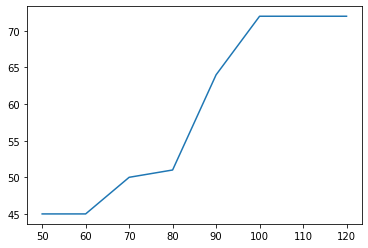

In [44]:
plt.plot(m_result[0], m_result[1])

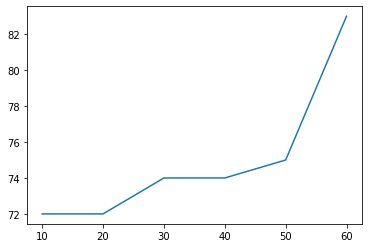

In [45]:
plt.plot(n_result[0], n_result[1])

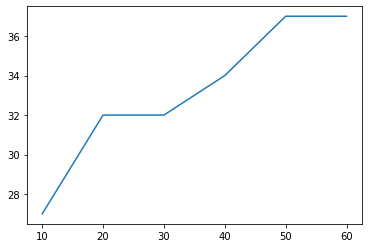

In [46]:
plt.plot(p_result[0], p_result[1])

In [57]:
from sklearn.model_selection import cross_val_score
all_r2 = []
for eachfile in final_xlsxs:
    all_X_qm, yields = descriptor_generator(eachfile)
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    all_X = all_X_qm
    result_matrix = np.zeros((2, 2))
    target = yields
    model = CatBoostRegressor(iterations=10000, random_seed=0, verbose=0, depth=2)
    all_r2.append(cross_val_score(model, all_X_qm, yields, cv=kf, scoring='r2').mean())
    print(all_r2[-1])                         


-2.541829782945582
-0.023590584007627237
-0.5046912022182373
0.4672065446712182
0.7123487736653658
0.6706388633918356
0.7386532143068321
0.7022277015086533
0.6925554127721333
0.7953203946721138
0.7198775433564018
0.772141674944623
0.7807233309909657
0.7840174923243334
0.7917703432252589
0.7709956282138515
0.7760377488690832
0.8011957583479076
0.7957782216313021
0.7433375744892033


(-0.5, 1.0)

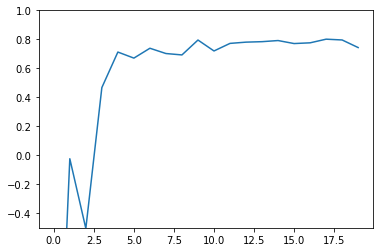

In [64]:
plt.plot(np.arange(len(all_r2)), all_r2)
plt.ylim(-0.5, 1)

### 每一轮对下一轮的预测

In [17]:
target_df = pd.read_excel("Data/Iteration/Result_sum_00021.xlsx")
len(target_df)

260

In [ ]:
all_r2s

100%|██████████| 21/21 [00:58<00:00,  2.81s/it]


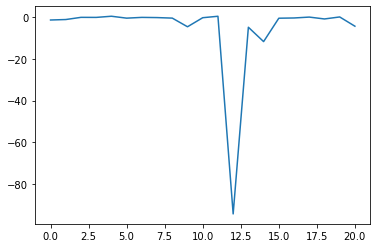

In [22]:
all_r2s = []
target_df = pd.read_excel("Data/Iteration/Result_sum_00021.xlsx")
for final_id in tqdm(range(60, len(target_df) + 10, 10)):
    train_df = target_df.iloc[:final_id - 10]
    test_df = target_df.iloc[final_id - 10:final_id]
    train_desc, train_yields = descriptor_generator(train_df)
    test_desc, test_yields = descriptor_generator(test_df)
    model = CatBoostRegressor(iterations=10000, random_seed=0, verbose=0, depth=2)
    model.fit(train_desc, train_yields)
    test_pred = model.predict(test_desc)
    all_r2s.append(r2_score(test_yields, test_pred))
plt.plot(np.arange(len(all_r2s)), all_r2s)


# 结果汇总

In [6]:
all_excels = glob.glob("Data/Iteration/机器学习脱氯条件3-*.xlsx")
new_df = pd.DataFrame()
for eachfile in all_excels:
    df = pd.read_excel(eachfile)
    new_df = pd.concat([new_df, df])
new_df.to_excel("Data/Iteration/汇总机器学习脱氯条件3-1~3-7.xlsx", index=False)

In [7]:
all_excels = glob.glob(r"D:\OneDrive_all\OneDrive\Work\work_part\12.B_radio_ene\Data\All_Data\Data_Structure_Update*.xlsx")
new_df = pd.DataFrame()
for eachfile in all_excels:
    df = pd.read_excel(eachfile)
    new_df = pd.concat([new_df, df])
new_df.to_excel(r"D:\OneDrive_all\OneDrive\Work\work_part\12.B_radio_ene\Data\All_Data\Data_Structure_Update_Sum.xlsx", index=False)

In [16]:
new_df[:0]

,Anime,Anime_Index,Phosphine,Phosphine_Index,NHC,NHC_Index,NHCS,NHCS_Index,Ar,Ar_Index,BR2,BR2_Index,Cl,Cl_Index


In [ ]:
Ar = new_df['NHC']
Ar = Ar[Ar.notnull()]

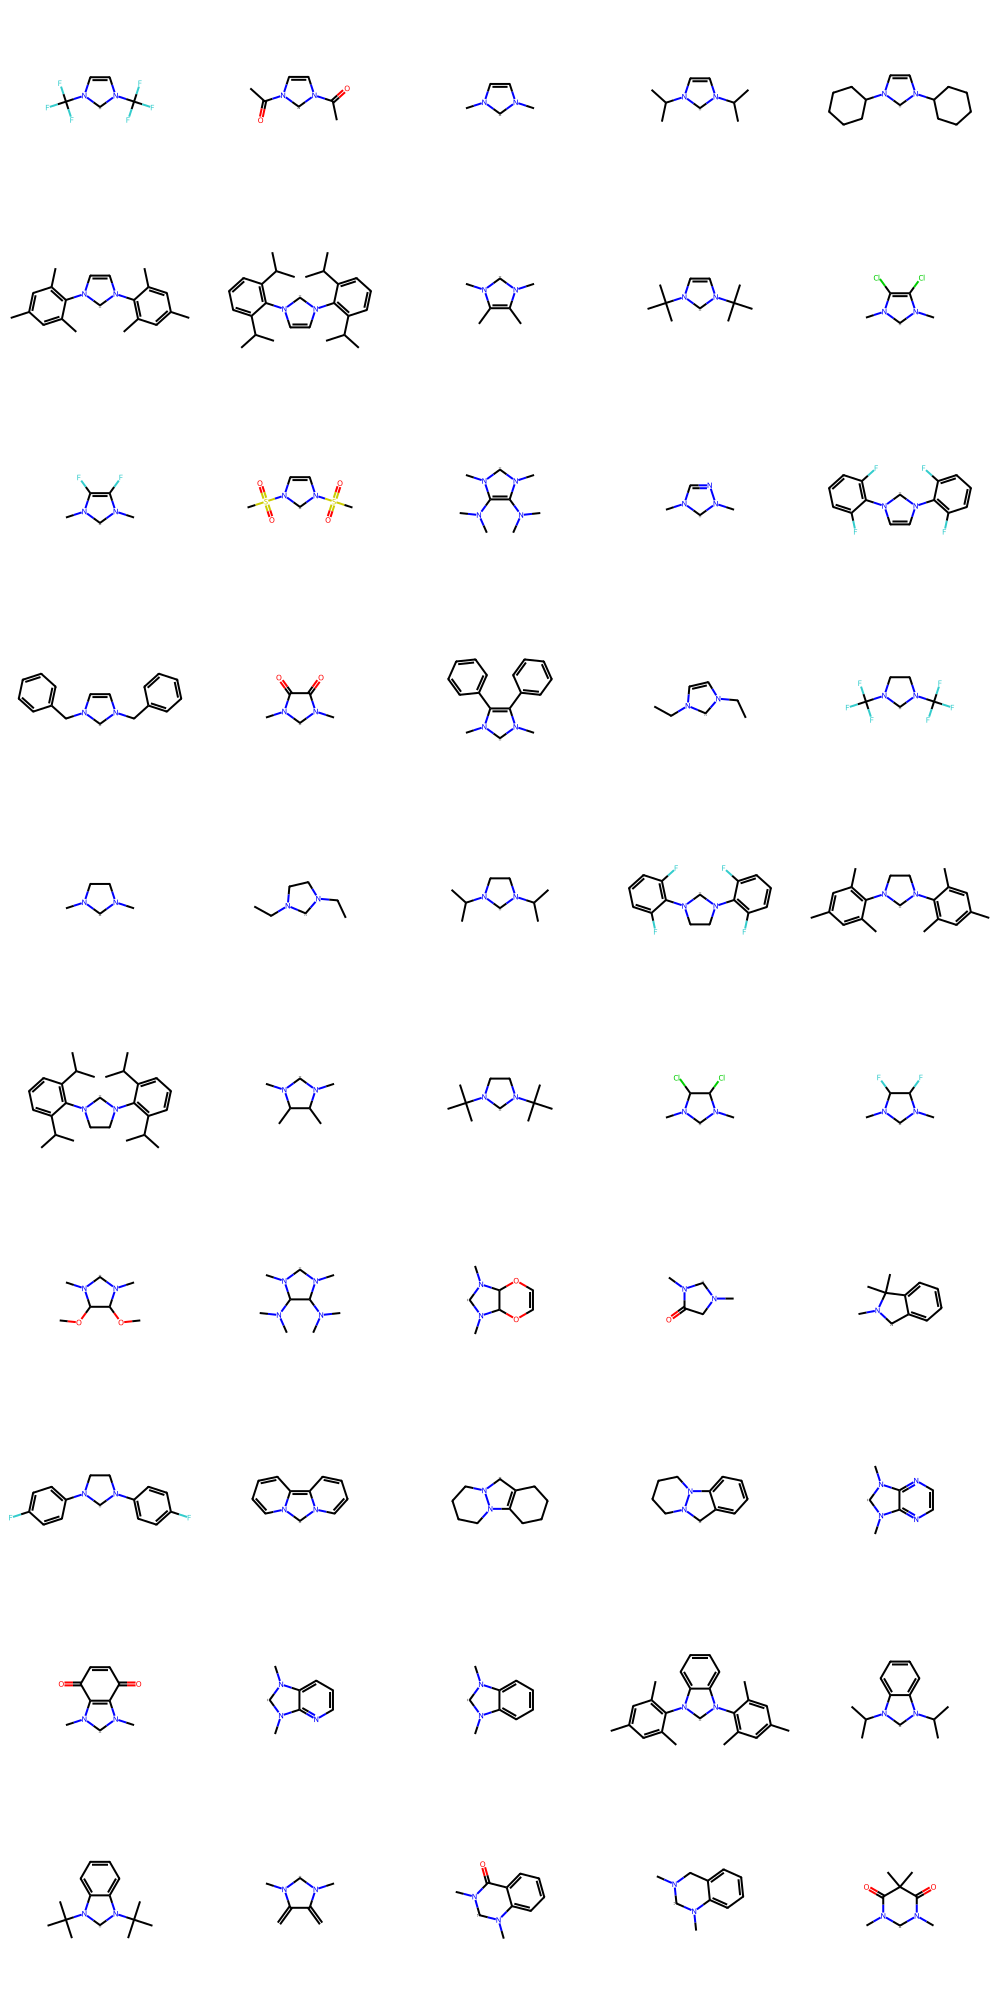

In [27]:
Chem.Draw.MolsToGridImage([Chem.MolFromSmiles(each) for each in Ar][0:], molsPerRow=5, subImgSize=(200, 200))

In [32]:
Chem.MolToSmiles(Chem.MolFromSmiles("ClC1=CC(C(OCCF)=O)=C(C=C1Cl)Cl"))

'O=C(OCCF)c1cc(Cl)c(Cl)cc1Cl'